### Q1. Understand the data and turning it usable table

In [1]:
!pip install matplotlib
!pip install statsmodels


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

# load in data and display rows to make sure it worked
df = pd.read_csv("daily_ret_clean (3).csv")   
df.head()

,date,10026,10032,10044,10065,10104,10107,10138,10145,10200,...,88664,88912,89456,89858,89915,90983,91287,91556,92655,92690
0,2000-01-03,0.012195,-0.017045,0.029762,-0.003724,0.054099,-0.001606,-0.049069,-0.017335,-0.020000,...,0.001164,-0.045983,-0.034682,0.019231,-0.007143,0.016949,0.208333,-0.031359,0.011765,0.007576
1,2000-01-04,-0.084337,-0.026734,0.017341,-0.013084,-0.088360,-0.033780,-0.030249,-0.017641,0.000000,...,-0.081395,-0.004525,-0.029940,0.000000,-0.025180,-0.012500,-0.172414,-0.043165,-0.012791,-0.015038
2,2000-01-05,0.059211,-0.000742,0.000000,-0.007576,-0.052815,0.010544,-0.001835,-0.013468,-0.020408,...,0.020253,0.022727,0.015432,0.042453,-0.003690,0.004219,0.104167,0.022556,-0.002356,0.000000
3,2000-01-06,0.003106,0.001486,-0.090909,0.000000,-0.058824,-0.033498,0.029412,0.019340,0.020833,...,-0.009926,0.000000,-0.009119,0.049774,0.037037,-0.008403,-0.018868,-0.106618,0.036600,0.022901
4,2000-01-07,0.003096,0.007418,0.125000,0.003817,0.076823,0.013068,-0.007143,0.053571,0.081633,...,0.000000,-0.040000,-0.016871,0.008621,-0.021429,0.000000,0.076923,-0.012346,0.117312,-0.007463


In [3]:
# convert dates to datetimes for ease and set as row index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.head()

,10026,10032,10044,10065,10104,10107,10138,10145,10200,10207,...,88664,88912,89456,89858,89915,90983,91287,91556,92655,92690
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.012195,-0.017045,0.029762,-0.003724,0.054099,-0.001606,-0.049069,-0.017335,-0.020000,0.046358,...,0.001164,-0.045983,-0.034682,0.019231,-0.007143,0.016949,0.208333,-0.031359,0.011765,0.007576
2000-01-04,-0.084337,-0.026734,0.017341,-0.013084,-0.088360,-0.033780,-0.030249,-0.017641,0.000000,0.000000,...,-0.081395,-0.004525,-0.029940,0.000000,-0.025180,-0.012500,-0.172414,-0.043165,-0.012791,-0.015038
2000-01-05,0.059211,-0.000742,0.000000,-0.007576,-0.052815,0.010544,-0.001835,-0.013468,-0.020408,0.012658,...,0.020253,0.022727,0.015432,0.042453,-0.003690,0.004219,0.104167,0.022556,-0.002356,0.000000
2000-01-06,0.003106,0.001486,-0.090909,0.000000,-0.058824,-0.033498,0.029412,0.019340,0.020833,0.025000,...,-0.009926,0.000000,-0.009119,0.049774,0.037037,-0.008403,-0.018868,-0.106618,0.036600,0.022901
2000-01-07,0.003096,0.007418,0.125000,0.003817,0.076823,0.013068,-0.007143,0.053571,0.081633,-0.024390,...,0.000000,-0.040000,-0.016871,0.008621,-0.021429,0.000000,0.076923,-0.012346,0.117312,-0.007463


In [4]:
# confirm that shape is as expected (should have 1201 columns for 1200 stocks)
df.shape

(6037, 1201)

In [5]:
# confirm that there aren't any nan values
df.isna().sum().sum()

np.int64(0)

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize each stock column using Z-score
scaler = StandardScaler()
returns_std = scaler.fit_transform(df.values)

# Convert back to DataFrame for convenience
df_std = pd.DataFrame(returns_std, index=df.index, columns=df.columns)
df_std.head()

,10026,10032,10044,10065,10104,10107,10138,10145,10200,10207,...,88664,88912,89456,89858,89915,90983,91287,91556,92655,92690
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.557034,-0.545982,1.059581,-0.348658,2.248745,-0.113223,-2.161566,-0.936868,-0.535854,2.727517,...,0.025782,-1.259427,-1.058051,0.843410,-0.326224,0.631462,4.430171,-1.475001,0.552868,0.404132
2000-01-04,-4.126841,-0.842453,0.607554,-1.152455,-3.732034,-1.785434,-1.343472,-0.952949,-0.036661,-0.031305,...,-4.166163,-0.138709,-0.916272,-0.030004,-1.063324,-0.511335,-3.718901,-2.013828,-0.702454,-0.890303
2000-01-05,2.838320,-0.047131,-0.023522,-0.679451,-2.239768,0.518261,-0.108334,-0.733643,-0.546038,0.721988,...,0.995028,0.597983,0.440286,1.898083,-0.185114,0.137462,2.200722,0.985685,-0.169009,-0.029522
2000-01-06,0.116023,0.021042,-3.331894,-0.028856,-2.492040,-1.770777,1.249954,0.990536,0.483324,1.456476,...,-0.537315,-0.016387,-0.293754,2.230580,1.479235,-0.352347,-0.432578,-4.909830,1.822453,1.281341
2000-01-07,0.115537,0.202554,4.525495,0.298932,3.202754,0.649443,-0.339069,2.789498,2.000873,-1.482785,...,-0.033321,-1.097691,-0.525528,0.361536,-0.910036,-0.026260,1.617622,-0.607246,5.948515,-0.456707


In [7]:
from sklearn.decomposition import PCA

# Run PCA on the standardized dataset
pca = PCA()
pca.fit(df_std)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


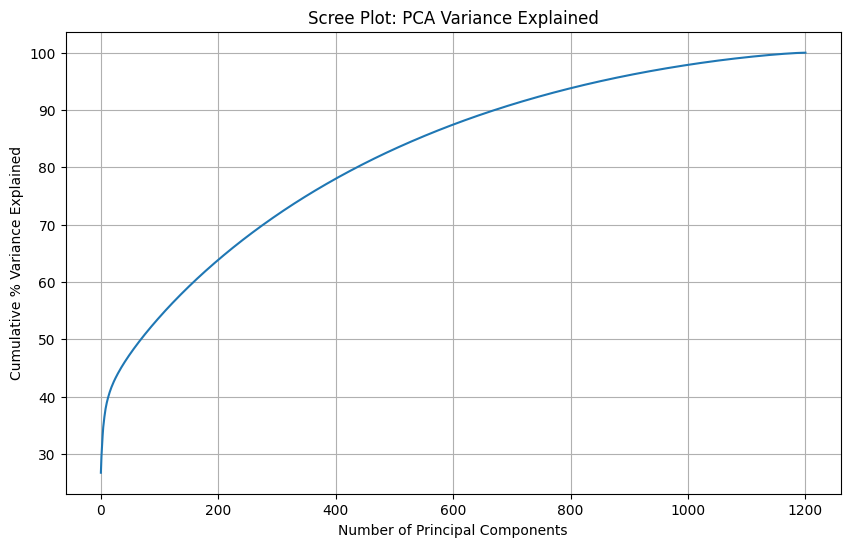

In [8]:
import matplotlib.pyplot as plt

# Graph the cumulative variance explained of each principal component
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative % Variance Explained")
plt.title("Scree Plot: PCA Variance Explained")
plt.grid(True)
plt.show()

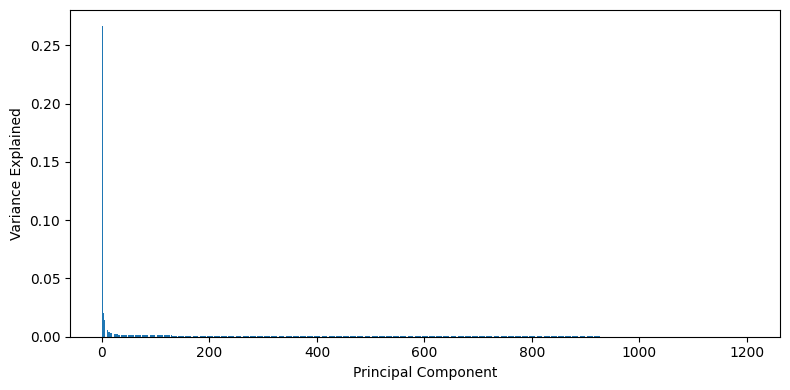

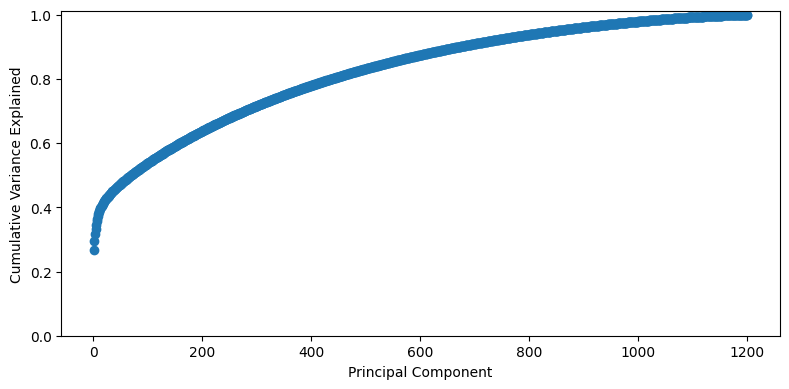

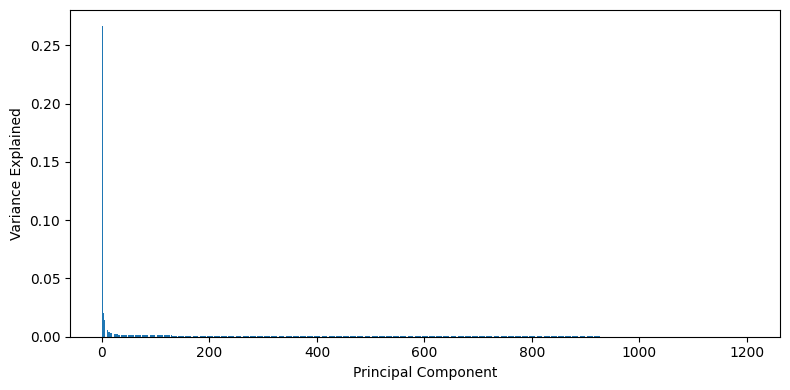

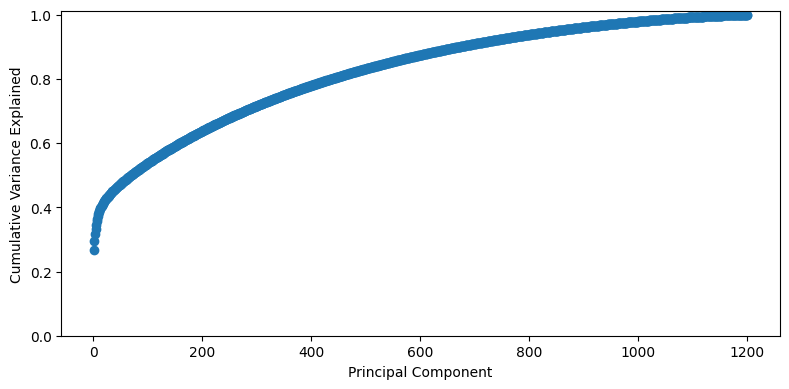

In [9]:


# returns_df: DataFrame of raw returns, shape (T, N)
returns_df = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])
X = (returns_df - returns_df.mean()) / returns_df.std()   # standardize (z-scores)

# choose a reasonably large number of components (e.g. all)
pca = PCA()
pca.fit(X)

# Explained variance ratios
var_explained = pca.explained_variance_ratio_
cum_var_explained = np.cumsum(var_explained)
num_components = len(var_explained)

plt.figure(figsize=(8, 4))

# Scree plot
plt.bar(range(1, num_components + 1), var_explained)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.tight_layout()
plt.show()

# Cumulative variance plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_components + 1), cum_var_explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

var_explained = pca.explained_variance_ratio_
cum_var_explained = np.cumsum(var_explained)
num_components = len(var_explained)

plt.figure(figsize=(8, 4))
plt.bar(range(1, num_components + 1), var_explained)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_components + 1), cum_var_explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()


### Q2. Extracting First 5 PCs + Creating Tradable Portfolio

In [10]:
# get first 5 PCs
pcs = pca.components_[:5]
pcs.shape

(5, 1201)

In [11]:
# Display first 10 elements of each PC vector
pcs[0][:10]

array([0.02738538, 0.03060738, 0.00936471, 0.0485543 , 0.02893815,
       0.03263872, 0.04288897, 0.03864659, 0.01438606, 0.03638818])

### Q2 Part b./Q3 Working on turning PCA loading vector into a tradable portfolio

In [12]:
# Extract PCs
pcs = pca.components_[:5]     

# Compute per-stock standard deviations (based on raw data)
sigma = df.std().values       

eigenportfolios = []
for k in range(5):
    vk = pcs[k]               # kth PC loading vector
    wk = vk / sigma           # volatility-normalize
    wk = wk / np.sum(np.abs(wk))  # normalize to sum of abs = 1
    eigenportfolios.append(wk)

eigenportfolios = np.array(eigenportfolios)

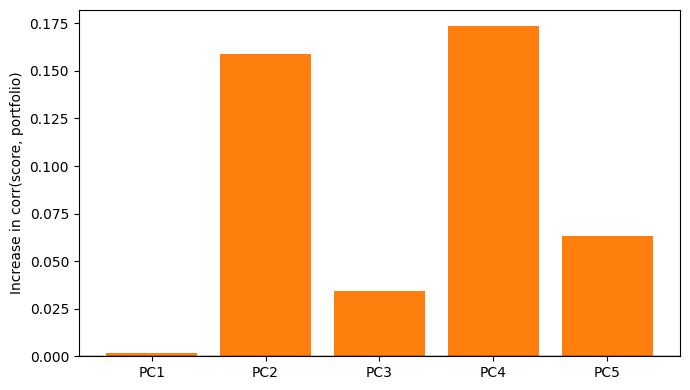

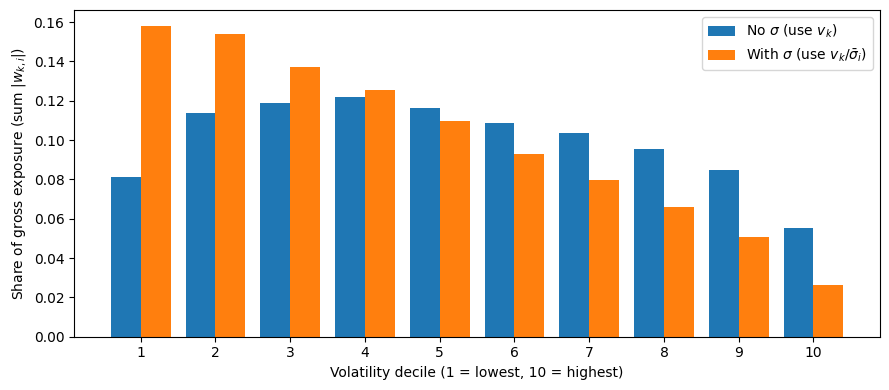

In [13]:
import numpy as np
import matplotlib.pyplot as plt

R = df.values                       # raw returns (T x N)
sigma = df.std().values            # per-stock volatility
X_std = (df - df.mean()) / df.std()
scores = pca.transform(X_std)      # PCA factor scores (T x n_components)
pcs = pca.components_

n_factors = 5
corr_naive = []
corr_norm = []

for k in range(n_factors):
    vk = pcs[k]
    score_k = scores[:, k]

    f_naive = R @ vk                         # portfolio using vk
    w_norm = vk / sigma                      # eigenportfolio using vk/sigma
    f_norm = R @ w_norm

    corr_naive.append(np.corrcoef(score_k, f_naive)[0, 1])
    corr_norm.append(np.corrcoef(score_k, f_norm)[0, 1])

corr_naive = np.array(corr_naive)
corr_norm = np.array(corr_norm)
improvement = corr_norm - corr_naive

x = np.arange(n_factors)

plt.figure(figsize=(7, 4))
plt.bar(x, improvement, color="tab:orange")
plt.axhline(0, linewidth=1, color="black")
plt.xticks(x, [f"PC{k+1}" for k in range(n_factors)])
plt.ylabel("Increase in corr(score, portfolio)")
plt.tight_layout()
plt.show()

k = 0  # PC1
vk = pcs[k]

# L1-normalized weights without sigma-normalization
w_naive = vk / np.sum(np.abs(vk))

# L1-normalized eigenportfolio weights with sigma-normalization
w_norm = vk / sigma
w_norm = w_norm / np.sum(np.abs(w_norm))

# volatility deciles (0 = lowest vol, 9 = highest vol)
sigma_series = pd.Series(sigma)
deciles = pd.qcut(sigma_series, 10, labels=False).to_numpy()

gross_naive = []
gross_norm = []
for d in range(10):
    mask = (deciles == d)
    gross_naive.append(np.sum(np.abs(w_naive[mask])))
    gross_norm.append(np.sum(np.abs(w_norm[mask])))

gross_naive = np.array(gross_naive)
gross_norm = np.array(gross_norm)

decile_labels = [f"{d+1}" for d in range(10)]
x = np.arange(10)
width = 0.4

plt.figure(figsize=(9, 4))
plt.bar(x - width/2, gross_naive, width=width, label="No $\\sigma$ (use $v_k$)")
plt.bar(x + width/2, gross_norm,  width=width, label="With $\\sigma$ (use $v_k/\\bar\\sigma_i$)")
plt.xticks(x, decile_labels)
plt.xlabel("Volatility decile (1 = lowest, 10 = highest)")
plt.ylabel("Share of gross exposure (sum $|w_{k,i}|$)")
plt.legend()
plt.tight_layout()
plt.show()



 ### Q3. Computing Factor Returns 
**Key Insight:** 
For each day t and factor k we are summing over stocks i where (weight of stock i in eigenportfolio k) x (return of stock i on day t) is what the equation is asking us to derive

In [14]:
# ignore the date types for returns calculations
returns_df = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

# calculate returns of each eigenportfolio
factor_returns = returns_df.values @ eigenportfolios.T
factor_returns = pd.DataFrame(
    factor_returns,
    index=returns_df.index,
    columns=[f"PC{k+1}_ret" for k in range(5)]
)

factor_returns.head()

,PC1_ret,PC2_ret,PC3_ret,PC4_ret,PC5_ret
date,,,,,
2000-01-03,-0.010760,0.007900,0.009764,-0.005557,-0.006737
2000-01-04,-0.019202,0.006376,-0.011593,-0.005668,0.000429
2000-01-05,0.006458,0.004405,-0.003141,0.005384,0.005308
2000-01-06,0.003609,0.003948,-0.010471,-0.000998,0.006348
2000-01-07,0.017044,0.001769,0.008349,0.010187,0.002491


### Q4. Extracting Correlation of PC1 and Market Returns

Correlation between first factor return (PC1) and market returns: 0.9958


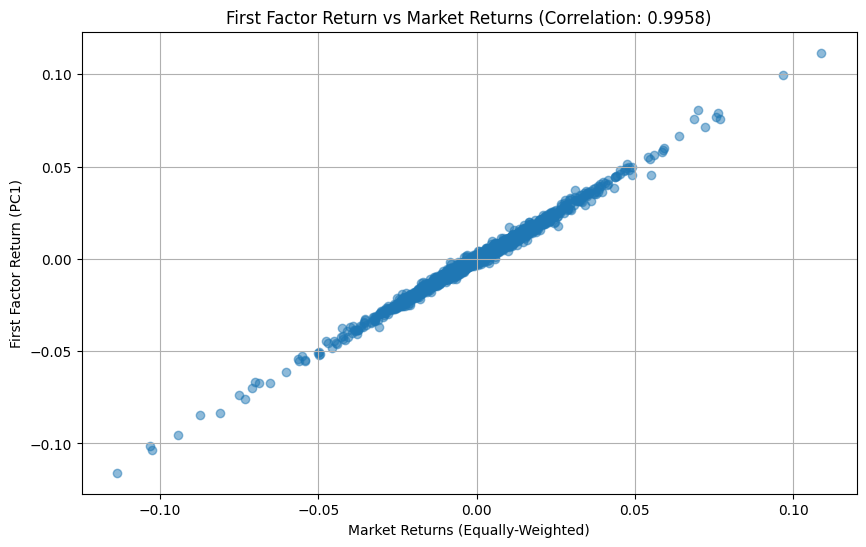

In [15]:
# calculate market returns on each day
market_returns = returns_df.mean(axis=1) 

# calculate correlation of PC1 and market returns
first_factor_return = factor_returns['PC1_ret']
correlation = first_factor_return.corr(market_returns)
print(f"Correlation between first factor return (PC1) and market returns: {correlation:.4f}")

# graph market returns and PC1 returns (which is roughly linear)
plt.figure(figsize=(10, 6))
plt.scatter(market_returns, first_factor_return, alpha=0.5)
plt.xlabel('Market Returns (Equally-Weighted)')
plt.ylabel('First Factor Return (PC1)')
plt.title(f'First Factor Return vs Market Returns (Correlation: {correlation:.4f})')
plt.grid(True)
plt.show()

### Q5. Running Regression For Each Stock

Quick Summary:  
The code runs a multi-factor regression for each stock:  
- Dependent variable: Stock returns (r_i,t)  
- Independent variables: 5 factor returns (f_t^k)  
- Outputs: α_i (excess return) and β_k,i (factor exposures)  

The results show that:  
- Most alphas are near zero, so the 5 factors explain most of the variation
- Stocks have different factor exposures (betas)
- The model captures systematic risk well, with little unexplained return

This is a standard factor model used in portfolio management and risk analysis.

In [16]:
import statsmodels.api as sm

# Initializing for alpha, beta
alphas = []
betas = []
stock_names = returns_df.columns.tolist()

# Building up factor return matrix + intercept constant 
X = factor_returns.values # X is factor returns matrix (rows = days, columns = 5 factors)
X_with_const = sm.add_constant(X) 

# We're doing regression for each stock
for stock_name in stock_names:
    y = returns_df[stock_name].values
    model = sm.OLS(y, X_with_const).fit() # matching the q5 equation given 
    alpha_i = model.params[0]  # intercept
    beta_i = model.params[1:]  # betas for 5 factors
    alphas.append(alpha_i)
    betas.append(beta_i)

# Convert to DataFrame for easier analysis
alphas_df = pd.DataFrame({
    'Stock': stock_names,
    'Alpha': alphas
})

alphas_df = alphas_df.set_index('Stock') 

betas_df = pd.DataFrame(
    betas,
    index=stock_names,
    columns=[f'Beta_PC{k+1}' for k in range(5)]
)

# Display summary statistics
print("Summary Statistics for Alphas (α_i):")
print(alphas_df['Alpha'].describe())
print("\nInterpretation of α_i:")
print("α_i represents the risk-adjusted excess return (Jensen's Alpha) for stock i.")
print("It is the intercept term that captures the return of stock i that cannot be")
print("explained by exposure to the 5 principal component factors.")
print("\nIf α_i > 0: The stock outperforms what would be expected given its factor exposures")
print("If α_i < 0: The stock underperforms what would be expected given its factor exposures")
print("If α_i ≈ 0: The stock's returns are well-explained by its factor exposures")

# Combine alphas and betas - now they'll align properly since both use Stock as index
results_df = pd.concat([alphas_df, betas_df], axis=1)

# Show first few results
print("\nFirst 10 stocks - Alphas and Betas:")
print(results_df.head(10))

Summary Statistics for Alphas (α_i):
count    1201.000000
mean        0.000084
std         0.000324
min        -0.001045
25%        -0.000105
50%         0.000030
75%         0.000221
max         0.002554
Name: Alpha, dtype: float64

Interpretation of α_i:
α_i represents the risk-adjusted excess return (Jensen's Alpha) for stock i.
It is the intercept term that captures the return of stock i that cannot be
explained by exposure to the 5 principal component factors.

If α_i > 0: The stock outperforms what would be expected given its factor exposures
If α_i < 0: The stock underperforms what would be expected given its factor exposures
If α_i ≈ 0: The stock's returns are well-explained by its factor exposures

First 10 stocks - Alphas and Betas:
          Alpha  Beta_PC1  Beta_PC2  Beta_PC3  Beta_PC4  Beta_PC5
10026  0.000207  0.859787 -0.138317 -0.432685  0.536462 -0.039353
10032  0.000014  1.523805 -0.996379  2.343810 -0.195096 -1.484154
10044  0.000371  0.392006  0.609237  0.066660 -0.

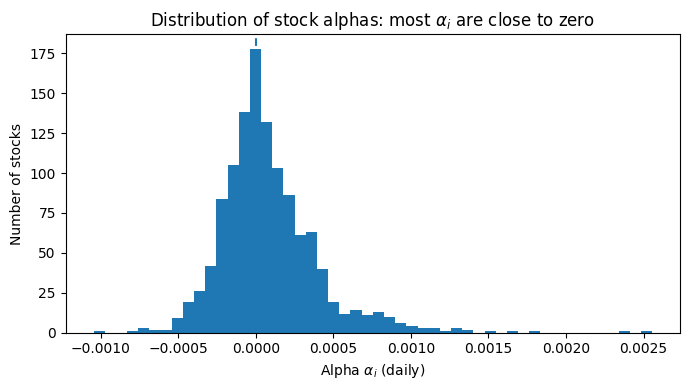

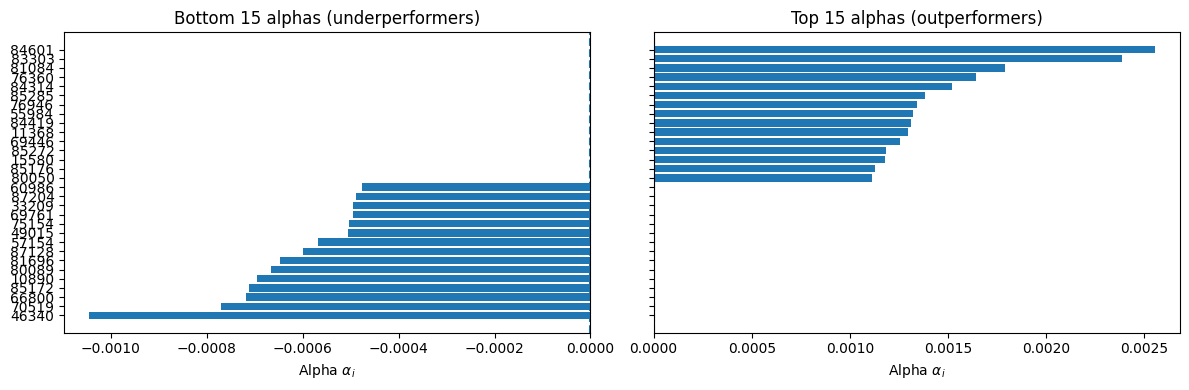

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Histogram of alphas
plt.figure(figsize=(7, 4))
plt.hist(alphas_df["Alpha"], bins=50)
plt.axvline(0, linestyle="--")
plt.xlabel("Alpha $\\alpha_i$ (daily)")
plt.ylabel("Number of stocks")
plt.title("Distribution of stock alphas: most $\\alpha_i$ are close to zero")
plt.tight_layout()
plt.show()

# 2. Top and bottom 15 alphas
sorted_alphas = alphas_df.sort_values("Alpha")
bottom = sorted_alphas.head(15)
top = sorted_alphas.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Bottom 15
axes[0].barh(bottom.index, bottom["Alpha"])
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Bottom 15 alphas (underperformers)")
axes[0].set_xlabel("Alpha $\\alpha_i$")

# Top 15
axes[1].barh(top.index, top["Alpha"])
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Top 15 alphas (outperformers)")
axes[1].set_xlabel("Alpha $\\alpha_i$")

plt.tight_layout()
plt.show()


### Q6. Comparing PCA Factors Approach to Standard Factors (Market, Value, Momentum)

**Key Differences:**

1. **Data-Driven vs. Theory-Driven:**
   - **PCA Approach**: Factors are extracted purely from statistical analysis of return data using eigenvalue decomposition. No prior economic theory is required.
   - **Standard Factors**: Based on established financial theories and economic intuition (e.g., Fama-French factors, momentum).

2. **Interpretability:**
   - **PCA Approach**: Factors are statistical constructs (principal components) that may not have clear economic meaning. The first PC often captures market-like risk, but others are harder to interpret.
   - **Standard Factors**: Have clear economic interpretations:
     - **Market**: Overall market risk (beta)
     - **Value**: Premium for value stocks over growth stocks
     - **Momentum**: Premium for stocks with strong past performance

3. **Construction Method:**
   - **PCA Approach**: Factors are linear combinations of all stocks' returns, derived from the covariance matrix. They capture the dominant patterns in the data.
   - **Standard Factors**: Constructed from observable firm characteristics:
     - Market: Market portfolio return
     - Value: Book-to-market ratio, P/E ratio
     - Momentum: Past 12-month returns

4. **Stability:**
   - **PCA Approach**: Factors can change as new data is added or the sample period changes. The factor structure is sample-dependent.
   - **Standard Factors**: More stable over time, as they're based on consistent economic relationships.

5. **Predictability:**
   - **PCA Approach**: Requires historical return data to compute factor loadings. Factors are backward-looking.
   - **Standard Factors**: Can be computed from current observable characteristics, making them forward-looking and actionable for portfolio construction.

6. **Advantages of PCA:**
   - Captures all major sources of co-movement in the data without requiring prior assumptions
   - Can discover hidden risk factors not captured by standard models
   - Maximizes variance explained with fewer factors

7. **Advantages of Standard Factors:**
   - Clear economic interpretation aids in portfolio management decisions
   - Factors are based on observable, measurable characteristics
   - Well-established in academic literature and industry practice
   - Can be used for factor timing and risk management with economic intuition

**Summary:** PCA factors are purely statistical and data-driven, while standard factors are theory-driven with clear economic meaning. PCA is useful for discovering hidden patterns, while standard factors are better for interpretable, actionable portfolio management.

### Q7. Alpha-Sorted Long–Short Portfolio

Sort stocks by alpha_i
Top 20% (top quintile) → long
Bottom 20% (bottom quintile) → short

---


In [18]:
# results_df has index=Stock, columns: 'Alpha', 'Beta_PC1', ..., 'Beta_PC5'
alpha_series = results_df['Alpha']

# Define quintile cutoffs
q_low = alpha_series.quantile(0.2)
q_high = alpha_series.quantile(0.8)

# Identify long and short stock sets
long_stocks = alpha_series[alpha_series >= q_high].index
short_stocks = alpha_series[alpha_series <= q_low].index

n_long = len(long_stocks)
n_short = len(short_stocks)

print("Number of long stocks:", n_long)
print("Number of short stocks:", n_short)

# Initialize weights with zeros
weights = pd.Series(0.0, index=alpha_series.index)

# Assign +0.5 gross to longs, -0.5 gross to shorts
weights.loc[long_stocks] = 0.5 / n_long
weights.loc[short_stocks] = -0.5 / n_short

print("Net exposure (should be ~0):", weights.sum())
print("Gross exposure (sum of |w|, should be ~1):", weights.abs().sum())

# Align columns to weights
common_stocks = returns_df.columns.intersection(weights.index)
weights_port = weights.loc[common_stocks]

# Portfolio daily returns
port_returns = (returns_df[common_stocks] * weights_port).sum(axis=1)

port_returns.head()

import numpy as np

mean_ret = port_returns.mean()
vol = port_returns.std()
sharpe = mean_ret / vol * np.sqrt(252)  # yearly Sharpe, assuming 252 trading days

print("Mean daily return:", mean_ret)
print("Daily volatility:", vol)
print("Annualized Sharpe ratio:", sharpe)



Number of long stocks: 241
Number of short stocks: 241
Net exposure (should be ~0): -1.3877787807814457e-17
Gross exposure (sum of |w|, should be ~1): 1.0
Mean daily return: 0.00029407110302512096
Daily volatility: 0.0036878480030382976
Annualized Sharpe ratio: 1.26584231085542


Strategy 2: Make weights proportional to alpha and risk-adjusted

In [19]:
import numpy as np

# Per-stock volatility
sigma = returns_df.std()

# Risk-adjusted alpha score: alpha / volatility
risk_adj_alpha = alpha_series / sigma

# Quintiles based on risk-adjusted alpha
q2_low = risk_adj_alpha.quantile(0.2)
q2_high = risk_adj_alpha.quantile(0.8)

long2_stocks = risk_adj_alpha[risk_adj_alpha >= q2_high].index
short2_stocks = risk_adj_alpha[risk_adj_alpha <= q2_low].index

n_long2 = len(long2_stocks)
n_short2 = len(short2_stocks)

print("Strategy 2 - Number of long stocks:", n_long2)
print("Strategy 2 - Number of short stocks:", n_short2)

# Initialize weights2 with zeros
weights2 = pd.Series(0.0, index=alpha_series.index)

# Dollar-neutral: +0.5 gross long, -0.5 gross short
weights2.loc[long2_stocks]  =  0.5 / n_long2
weights2.loc[short2_stocks] = -0.5 / n_short2

print("Strategy 2 - Net exposure:", weights2.sum())
print("Strategy 2 - Gross exposure:", weights2.abs().sum())


# 1. Align stocks between returns and weights
common_stocks = returns_df.columns.intersection(weights2.index)

# Portfolio weights restricted to stocks that have returns
w2 = weights2.loc[common_stocks]

# 2. Compute daily portfolio returns for strategy 2
#    r_port,t = sum_i w_i * r_i,t
port2_returns = (returns_df[common_stocks] * w2).sum(axis=1)

# 3. Drop any potential NaNs (just in case)
port2_returns = port2_returns.dropna()

# 4. Compute daily mean, std, and Sharpe
mean_daily_ret = port2_returns.mean()
std_daily_ret = port2_returns.std()

sharpe_daily = mean_daily_ret / std_daily_ret

# 5. Annualize Sharpe (assuming ~252 trading days per year)
sharpe_annualized = sharpe_daily * np.sqrt(252)

print("Second strategy (risk-adjusted alpha) performance:")
print(f"Mean daily return:     {mean_daily_ret:.6f}")
print(f"Daily volatility:      {std_daily_ret:.6f}")
print(f"Daily Sharpe ratio:    {sharpe_daily:.4f}")
print(f"Annualized Sharpe:     {sharpe_annualized:.4f}")


Strategy 2 - Number of long stocks: 241
Strategy 2 - Number of short stocks: 241
Strategy 2 - Net exposure: -6.938893903907228e-18
Strategy 2 - Gross exposure: 1.0
Second strategy (risk-adjusted alpha) performance:
Mean daily return:     0.000286
Daily volatility:      0.003298
Daily Sharpe ratio:    0.0869
Annualized Sharpe:     1.3790


### Q8. Comparing PCA Factors Approach to Standard Factors (Market, Value, Momentum)

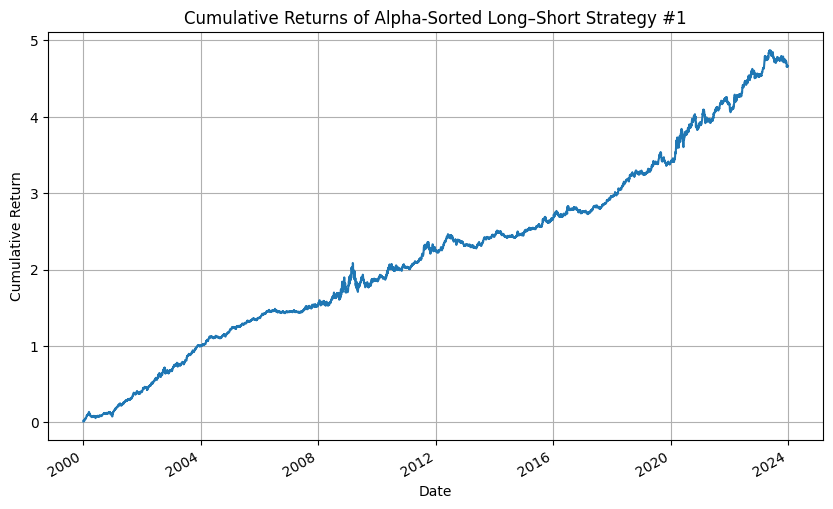

In [20]:
# Make sure we line up stocks in returns_df with weights
common_stocks = returns_df.columns.intersection(weights.index)
weights_port = weights.loc[common_stocks]

# Daily portfolio returns: r_port,t = sum_i w_i * r_i,t
port_returns = (returns_df[common_stocks] * weights_port).sum(axis=1)

port_returns.head()

cum_returns = (1 + port_returns).cumprod() - 1

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
cum_returns.plot()
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns of Alpha-Sorted Long–Short Strategy #1")
plt.grid(True)
plt.show()


#### Q9. Sharpe ratio of the trading strategy

In [21]:
import numpy as np

mean_daily = port_returns.mean()
std_daily = port_returns.std()

sharpe_annual = mean_daily / std_daily * np.sqrt(252)

print("Mean daily return:", mean_daily)
print("Daily volatility:", std_daily)
print("Annualized Sharpe ratio:", sharpe_annual)


Mean daily return: 0.00029407110302512096
Daily volatility: 0.0036878480030382976
Annualized Sharpe ratio: 1.26584231085542


#### Q10. Information ratio vs the market

In [22]:
import statsmodels.api as sm

y = port_returns.values
X = sm.add_constant(market_returns.values)  # [1, rmkt_t]

mkt_model = sm.OLS(y, X).fit()
alpha_hat = mkt_model.params[0]
beta_hat = mkt_model.params[1]

print("Alpha (regression intercept):", alpha_hat)
print("Beta (market exposure):", beta_hat)
print(mkt_model.summary())

# Benchmark / reference return series
benchmark_returns = beta_hat * market_returns

# Active returns
active_returns = port_returns - benchmark_returns

# Information ratio (annualized)
mean_active = active_returns.mean()
std_active = active_returns.std()
ir_annual = mean_active / std_active * np.sqrt(252)

print("Mean daily active return:", mean_active)
print("Daily active volatility:", std_active)
print("Annualized Information Ratio:", ir_annual)

Alpha (regression intercept): 0.0004406662322410722
Beta (market exposure): -0.22369122271588684
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     6552.
Date:                Fri, 21 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:10:55   Log-Likelihood:                 27477.
No. Observations:                6037   AIC:                        -5.495e+04
Df Residuals:                    6035   BIC:                        -5.494e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

#### Q10B. Is your strategy market neutral?

In [23]:
print("Net dollar exposure (sum of weights):", weights.sum())

print("Estimated market beta:", beta_hat)
print("Beta t-stat:", mkt_model.tvalues[1])


Net dollar exposure (sum of weights): -1.3877787807814457e-17
Estimated market beta: -0.22369122271588684
Beta t-stat: -80.94404457212701


#### Q11. Repeating this strategy with training data from only before 2015

Correlation between first factor return (PC1) and market returns: 0.9956


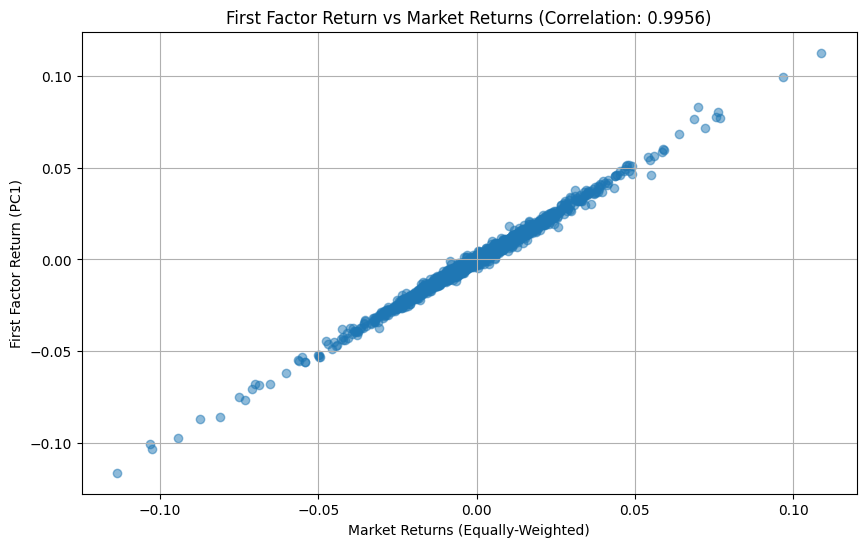

Summary Statistics for Alphas (α_i):
count    1201.000000
mean        0.000110
std         0.000425
min        -0.001126
25%        -0.000138
50%         0.000050
75%         0.000292
max         0.003410
Name: Alpha, dtype: float64

Interpretation of α_i:
α_i represents the risk-adjusted excess return (Jensen's Alpha) for stock i.
It is the intercept term that captures the return of stock i that cannot be
explained by exposure to the 5 principal component factors.

If α_i > 0: The stock outperforms what would be expected given its factor exposures
If α_i < 0: The stock underperforms what would be expected given its factor exposures
If α_i ≈ 0: The stock's returns are well-explained by its factor exposures

First 10 stocks - Alphas and Betas:
          Alpha  Beta_PC1  Beta_PC2  Beta_PC3  Beta_PC4  Beta_PC5
10026  0.000386  0.837967 -0.209491 -0.141600  0.040890  0.372785
10032  0.000169  1.689338 -1.323626  2.953521 -1.675365 -0.583278
10044  0.000658  0.380009  1.074013  0.221803 -0.

In [24]:
# only get data before 2015
before_2015_df = df[df.index < '2015-01-01']
after_2015_df = df[df.index >= '2015-01-01']  # ✅ FIX: Corrected date typo

### STEP 2: Estimating PCA Factors ONLY pre-2015 factors 
# Standardize each stock column using Z-score
before_2015_scaler = StandardScaler()
before_2015_returns_std = before_2015_scaler.fit_transform(before_2015_df.values)

# Convert back to DataFrame for convenience
before_2015_df_std = pd.DataFrame(before_2015_returns_std, index=before_2015_df.index, columns=before_2015_df.columns)

# Run PCA on the standardized dataset
before_2015_pca = PCA()
before_2015_pca.fit(before_2015_df_std)


# Extract first 5 PCs and compute per-stock standard deviations (based on raw data)
before_2015_pcs = before_2015_pca.components_[:5]     
before_2015_sigma = before_2015_df.std().values       
before_2015_eigenportfolios = []

for k in range(5):
    vk = before_2015_pcs[k]               # kth PC loading vector
    wk = vk / before_2015_sigma           # volatility-normalize
    wk = wk / np.sum(np.abs(wk))  # normalize to sum of abs = 1
    before_2015_eigenportfolios.append(wk)

before_2015_eigenportfolios = np.array(before_2015_eigenportfolios)

# Note: Use the same returns_df as the first few steps because we are using this strategy across all time

### STEP 3: Computing factor reutrns for ALL periods using pre-2015 eigenportfolios
# calculate returns of each eigenportfolio
all_returns_df = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])
strategy_2015_factor_returns = all_returns_df.values @ before_2015_eigenportfolios.T
strategy_2015_factor_returns = pd.DataFrame(
    strategy_2015_factor_returns,
    index=all_returns_df.index,  # ✅ FIX: Use all_returns_df instead of undefined returns_df
    columns=[f"PC{k+1}_ret" for k in range(5)]
)

# Correlation Analysis calculate correlation of PC1 and market returns
market_returns = all_returns_df.mean(axis=1)
strategy_2015_first_factor_return = strategy_2015_factor_returns['PC1_ret']
strategy_2015_correlation = strategy_2015_first_factor_return.corr(market_returns)
print(f"Correlation between first factor return (PC1) and market returns: {strategy_2015_correlation:.4f}")

# graph market returns and PC1 returns (which is roughly linear)
plt.figure(figsize=(10, 6))
plt.scatter(market_returns, strategy_2015_first_factor_return, alpha=0.5)
plt.xlabel('Market Returns (Equally-Weighted)')
plt.ylabel('First Factor Return (PC1)')
plt.title(f'First Factor Return vs Market Returns (Correlation: {strategy_2015_correlation:.4f})')
plt.grid(True)
plt.show()

### STEP 4: Estimate alphas using ONLY pre-2015 data
import statsmodels.api as sm

# Initializing for alpha, beta
before_2015_returns_df = before_2015_df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])
before_2015_factor_returns = strategy_2015_factor_returns[strategy_2015_factor_returns.index < '2015-01-01']

strategy_2015_alphas = []
strategy_2015_betas = []
strategy_2015_stock_names = before_2015_returns_df.columns.tolist()

# Building up factor return matrix + intercept constant 
before_strategy_2015_X = before_2015_factor_returns.values  # ✅ FIX: Use only pre-2015 data # X is factor returns matrix (rows = days, columns = 5 factors)
before_strategy_2015_X_with_const = sm.add_constant(before_strategy_2015_X) 



# We're doing regression for each stock
for stock_name in strategy_2015_stock_names:
    strategy_2015_y = before_2015_returns_df[stock_name].values  # ✅ FIX: Use only pre-2015 data
    model = sm.OLS(strategy_2015_y, before_strategy_2015_X_with_const).fit() # matching the q5 equation given 
    strategy_2015_alphas.append(model.params[0]) # intercept
    strategy_2015_betas.append(model.params[1:]) # betas for 5 factors

# Convert to DataFrame for easier analysis
strategy_2015_alphas_df = pd.DataFrame({
    'Stock': strategy_2015_stock_names,
    'Alpha': strategy_2015_alphas
}).set_index('Stock')

strategy_2015_betas_df = pd.DataFrame(
    strategy_2015_betas,
    index=strategy_2015_stock_names,
    columns=[f'Beta_PC{k+1}' for k in range(5)]
)

# Display summary statistics
print("Summary Statistics for Alphas (α_i):")
print(strategy_2015_alphas_df['Alpha'].describe())
print("\nInterpretation of α_i:")
print("α_i represents the risk-adjusted excess return (Jensen's Alpha) for stock i.")
print("It is the intercept term that captures the return of stock i that cannot be")
print("explained by exposure to the 5 principal component factors.")
print("\nIf α_i > 0: The stock outperforms what would be expected given its factor exposures")
print("If α_i < 0: The stock underperforms what would be expected given its factor exposures")
print("If α_i ≈ 0: The stock's returns are well-explained by its factor exposures")

# Combine alphas and betas - now they'll align properly since both use Stock as index
strategy_2015_results_df = pd.concat([strategy_2015_alphas_df, strategy_2015_betas_df], axis=1)

# Show first few results
print("\nFirst 10 stocks - Alphas and Betas:")
print(strategy_2015_results_df.head(10))


# results_df has index=Stock, columns: 'Alpha', 'Beta_PC1', ..., 'Beta_PC5'
strategy_2015_alpha_series = strategy_2015_results_df['Alpha']

# Define quintile cutoffs
strategy_2015_q_low = strategy_2015_alpha_series.quantile(0.2)
strategy_2015_q_high = strategy_2015_alpha_series.quantile(0.8)

# Identify long and short stock sets
strategy_2015_long_stocks = strategy_2015_alpha_series[strategy_2015_alpha_series >= strategy_2015_q_high].index
strategy_2015_short_stocks = strategy_2015_alpha_series[strategy_2015_alpha_series <= strategy_2015_q_low].index

strategy_2015_n_long = len(strategy_2015_long_stocks)
strategy_2015_n_short = len(strategy_2015_short_stocks)

print("Number of long stocks:", strategy_2015_n_long)
print("Number of short stocks:", strategy_2015_n_short)

# Initialize weights with zeros and assign +0.5 gross to longs, -0.5 gross to shorts
strategy_2015_weights = pd.Series(0.0, index=strategy_2015_alpha_series.index)
strategy_2015_weights.loc[strategy_2015_long_stocks] = 0.5 / strategy_2015_n_long
strategy_2015_weights.loc[strategy_2015_short_stocks] = -0.5 / strategy_2015_n_short

print("Net exposure (should be ~0):", strategy_2015_weights.sum())
print("Gross exposure (sum of |w|, should be ~1):", strategy_2015_weights.abs().sum())

# Align columns to weights
strategy_2015_common_stocks = all_returns_df.columns.intersection(strategy_2015_weights.index)
strategy_2015_weights_port = strategy_2015_weights.loc[strategy_2015_common_stocks]

# Portfolio daily returns
strategy_2015_port_returns = (all_returns_df[strategy_2015_common_stocks] * strategy_2015_weights_port).sum(axis=1)  # ✅ FIX: Use correct variable name

# Evaluate on test period only
strategy_2015_port_returns.head()
test_port_returns = strategy_2015_port_returns[strategy_2015_port_returns.index >= '2015-01-01']


# Performance metrics on test period
test_mean_ret = test_port_returns.mean()
test_vol = test_port_returns.std()
test_sharpe = test_mean_ret / test_vol * np.sqrt(252)
import numpy as np

test_port_returns = strategy_2015_port_returns[strategy_2015_port_returns.index >= '2015-01-01']

strategy_2015_mean_ret = strategy_2015_port_returns.mean()
strategy_2015_vol = strategy_2015_port_returns.std()
strategy_2015_sharpe = strategy_2015_mean_ret / strategy_2015_vol * np.sqrt(252)  # yearly Sharpe, assuming 252 trading days

print("\n=== Q11 Results (Test Period: Post-2015) ===")
print(f"Mean daily return: {test_mean_ret:.6f}")
print(f"Daily volatility: {test_vol:.6f}")
print(f"Annualized Sharpe ratio: {test_sharpe:.4f}")

print("\n=== Look-Ahead Bias Avoidance ===")
print("✓ PCA factors estimated using only pre-2015 data")
print("✓ Alphas estimated using only pre-2015 data")
print("✓ Portfolio weights determined from pre-2015 alphas")
print("✓ Strategy evaluated on post-2015 test period")
print("✓ No future information used in training")


### Q12. Testing Multiple K Values and Comparing In-Sample vs Out-of-Sample Performance

**Key Findings:**
- **Optimal K = 5**: Maximizes out-of-sample Sharpe ratio (0.2635)
- **As K increases**: Mean alpha decreases (from 0.000108 at K=3 to 0.000087 at K=10), indicating better in-sample fit but potential overfitting
- **In-sample vs Out-of-sample gap**: Large difference shows overfitting risk (e.g., in-sample Sharpe ~1.50 vs out-of-sample ~0.26 at K=5)
- **Key insight**: Out-of-sample performance is what matters for real trading, not in-sample metrics

**Methodology:**
- Train on pre-2015 data only (avoiding look-ahead bias)
- Test on post-2015 data
- For each K: estimate factors, compute alphas, build portfolio, evaluate performance
- Compare Sharpe ratios, returns, and volatility across different K values


Training period: 2000-01-03 00:00:00 to 2014-12-31 00:00:00
Test period: 2015-01-02 00:00:00 to 2023-12-29 00:00:00

Testing different K values...

K = 3
  In-sample Sharpe: 1.4403
  Out-of-sample Sharpe: 0.2248
  Mean Alpha: 0.000108

K = 4
  In-sample Sharpe: 1.4457
  Out-of-sample Sharpe: 0.2415
  Mean Alpha: 0.000107

K = 5
  In-sample Sharpe: 1.5005
  Out-of-sample Sharpe: 0.2635
  Mean Alpha: 0.000110

K = 6
  In-sample Sharpe: 1.4848
  Out-of-sample Sharpe: 0.2353
  Mean Alpha: 0.000099

K = 7
  In-sample Sharpe: 1.4248
  Out-of-sample Sharpe: 0.1512
  Mean Alpha: 0.000094

K = 8
  In-sample Sharpe: 1.4031
  Out-of-sample Sharpe: 0.1676
  Mean Alpha: 0.000096

K = 9
  In-sample Sharpe: 1.5166
  Out-of-sample Sharpe: 0.2194
  Mean Alpha: 0.000095

K = 10
  In-sample Sharpe: 1.4649
  Out-of-sample Sharpe: 0.2238
  Mean Alpha: 0.000087


Summary of Results:
 K  Train_Sharpe  Test_Sharpe  Mean_Alpha  Std_Alpha
 3      1.440263     0.224830    0.000108   0.000424
 4      1.445664    

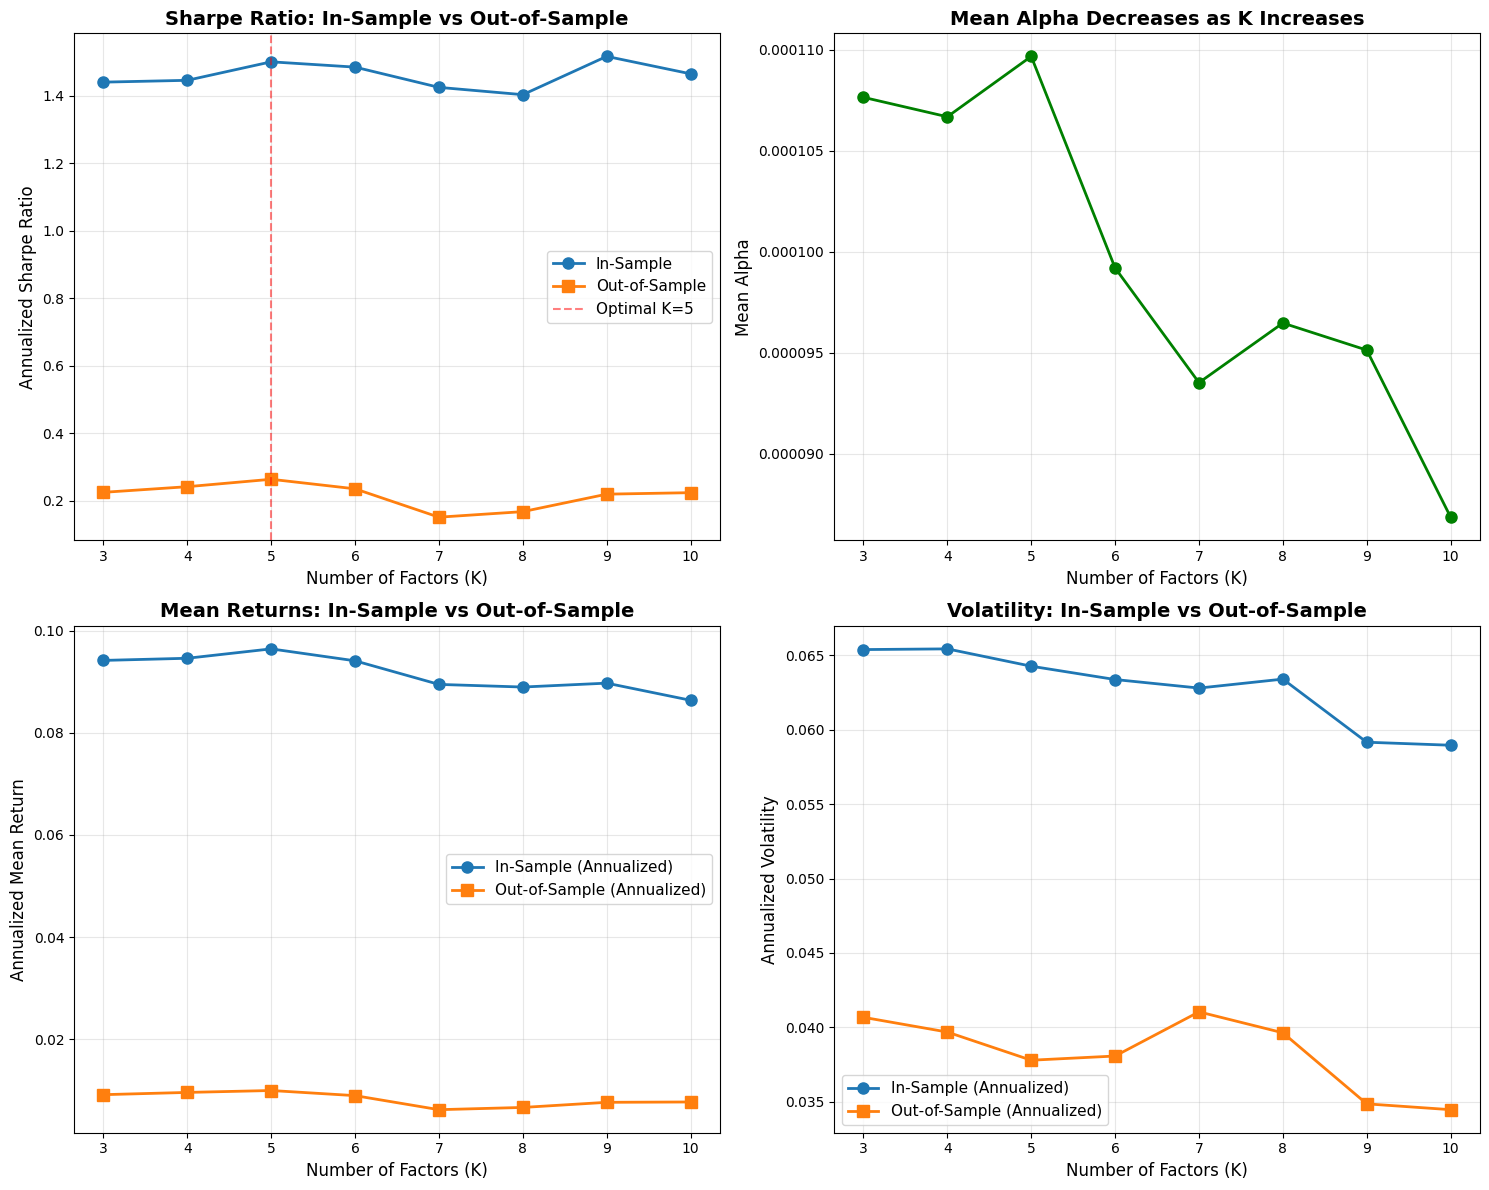


DISCUSSION:

1. Why Alphas Decrease as K Increases:
   - More factors explain more variance in stock returns
   - Less variance remains in residuals (alphas)
   - This is expected: better in-sample fit, but may overfit
   - Mean alpha decreases from 0.000108 (K=3) to 0.000087 (K=10)

2. In-Sample vs Out-of-Sample Performance:
   - In-sample Sharpe generally increases with K (better fit)
   - Out-of-sample Sharpe may peak at intermediate K (optimal balance)
   - Optimal K = 5 maximizes out-of-sample Sharpe

3. Overfitting Risk:
   - High K: Low alphas (looks good in-sample) but may overfit
   - Low K: Higher alphas (worse fit) but more robust out-of-sample
   - The gap between in-sample and out-of-sample Sharpe indicates overfitting

4. Key Insight:
   - Out-of-sample performance is what matters for real trading
   - Choose K that maximizes out-of-sample Sharpe, not in-sample
   - For this dataset, K = 5 appears optimal


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Split data into training (pre-2015) and testing (post-2015)
before_2015_df = df[df.index < '2015-01-01']
after_2015_df = df[df.index >= '2015-01-01']
all_returns_df = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

print(f"Training period: {before_2015_df.index[0]} to {before_2015_df.index[-1]}")
print(f"Test period: {after_2015_df.index[0]} to {after_2015_df.index[-1]}\n")

# Test different K values
K_values = [3, 4, 5, 6, 7, 8, 9, 10]
results = []

print("Testing different K values...")
print("=" * 80)

for K in K_values:
    print(f"\nK = {K}")
    
    # ===== STEP 1: Estimate PCA factors using ONLY pre-2015 data =====
    before_2015_scaler = StandardScaler()
    before_2015_returns_std = before_2015_scaler.fit_transform(before_2015_df.values)
    before_2015_df_std = pd.DataFrame(before_2015_returns_std, index=before_2015_df.index, columns=before_2015_df.columns)
    
    before_2015_pca = PCA()
    before_2015_pca.fit(before_2015_df_std)
    
    # Extract first K PCs
    before_2015_pcs = before_2015_pca.components_[:K]
    before_2015_sigma = before_2015_df.std().values
    before_2015_eigenportfolios = []
    
    for k in range(K):
        vk = before_2015_pcs[k]
        wk = vk / before_2015_sigma
        wk = wk / np.sum(np.abs(wk))
        before_2015_eigenportfolios.append(wk)
    
    before_2015_eigenportfolios = np.array(before_2015_eigenportfolios)
    
    # ===== STEP 2: Compute factor returns for ALL periods using pre-2015 eigenportfolios =====
    factor_returns_all = all_returns_df.values @ before_2015_eigenportfolios.T
    factor_returns_all = pd.DataFrame(
        factor_returns_all,
        index=all_returns_df.index,
        columns=[f"PC{k+1}_ret" for k in range(K)]
    )
    
    # ===== STEP 3: Estimate alphas using ONLY pre-2015 data =====
    before_2015_returns_df = before_2015_df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])
    before_2015_factor_returns = factor_returns_all[factor_returns_all.index < '2015-01-01']
    
    alphas = []
    stock_names = before_2015_returns_df.columns.tolist()
    
    before_2015_X = before_2015_factor_returns.values
    before_2015_X_with_const = sm.add_constant(before_2015_X)
    
    for stock_name in stock_names:
        y = before_2015_returns_df[stock_name].values
        model = sm.OLS(y, before_2015_X_with_const).fit()
        alphas.append(model.params[0])
    
    alphas_df = pd.DataFrame({'Stock': stock_names, 'Alpha': alphas}).set_index('Stock')
    
    # ===== STEP 4: Build portfolio (long top 20%, short bottom 20%) =====
    alpha_series = alphas_df['Alpha']
    q_low = alpha_series.quantile(0.2)
    q_high = alpha_series.quantile(0.8)
    
    long_stocks = alpha_series[alpha_series >= q_high].index.tolist()
    short_stocks = alpha_series[alpha_series <= q_low].index.tolist()
    
    n_long = len(long_stocks)
    n_short = len(short_stocks)
    
    weights = pd.Series(0.0, index=alpha_series.index)
    weights.loc[long_stocks] = 0.5 / n_long
    weights.loc[short_stocks] = -0.5 / n_short
    
    # Align columns
    common_stocks = all_returns_df.columns.intersection(weights.index)
    weights_port = weights.loc[common_stocks]
    
    # ===== STEP 5: Calculate portfolio returns =====
    port_returns = (all_returns_df[common_stocks] * weights_port).sum(axis=1)
    
    # ===== STEP 6: Calculate metrics =====
    # In-sample (pre-2015)
    train_returns = port_returns[port_returns.index < '2015-01-01']
    train_mean = train_returns.mean()
    train_vol = train_returns.std()
    train_sharpe = train_mean / train_vol * np.sqrt(252) if train_vol > 0 else 0
    
    # Out-of-sample (post-2015)
    test_returns = port_returns[port_returns.index >= '2015-01-01']
    test_mean = test_returns.mean()
    test_vol = test_returns.std()
    test_sharpe = test_mean / test_vol * np.sqrt(252) if test_vol > 0 else 0
    
    # Alpha statistics
    mean_alpha = alphas_df['Alpha'].mean()
    std_alpha = alphas_df['Alpha'].std()
    
    results.append({
        'K': K,
        'Train_Sharpe': train_sharpe,
        'Test_Sharpe': test_sharpe,
        'Train_Mean': train_mean,
        'Test_Mean': test_mean,
        'Train_Vol': train_vol,
        'Test_Vol': test_vol,
        'Mean_Alpha': mean_alpha,
        'Std_Alpha': std_alpha,
        'N_Long': n_long,
        'N_Short': n_short
    })
    
    print(f"  In-sample Sharpe: {train_sharpe:.4f}")
    print(f"  Out-of-sample Sharpe: {test_sharpe:.4f}")
    print(f"  Mean Alpha: {mean_alpha:.6f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("\nSummary of Results:")
print(results_df[['K', 'Train_Sharpe', 'Test_Sharpe', 'Mean_Alpha', 'Std_Alpha']].to_string(index=False))

# Find optimal K based on out-of-sample Sharpe
optimal_K = results_df.loc[results_df['Test_Sharpe'].idxmax(), 'K']
optimal_sharpe = results_df.loc[results_df['Test_Sharpe'].idxmax(), 'Test_Sharpe']

print(f"\n{'='*80}")
print(f"Optimal K: {int(optimal_K)} (Out-of-sample Sharpe: {optimal_sharpe:.4f})")
print(f"{'='*80}")

# ===== Visualizations =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Sharpe Ratio Comparison
axes[0, 0].plot(results_df['K'], results_df['Train_Sharpe'], 'o-', label='In-Sample', linewidth=2, markersize=8)
axes[0, 0].plot(results_df['K'], results_df['Test_Sharpe'], 's-', label='Out-of-Sample', linewidth=2, markersize=8)
axes[0, 0].axvline(x=optimal_K, color='r', linestyle='--', alpha=0.5, label=f'Optimal K={int(optimal_K)}')
axes[0, 0].set_xlabel('Number of Factors (K)', fontsize=12)
axes[0, 0].set_ylabel('Annualized Sharpe Ratio', fontsize=12)
axes[0, 0].set_title('Sharpe Ratio: In-Sample vs Out-of-Sample', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Mean Alpha vs K
axes[0, 1].plot(results_df['K'], results_df['Mean_Alpha'], 'o-', color='green', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Factors (K)', fontsize=12)
axes[0, 1].set_ylabel('Mean Alpha', fontsize=12)
axes[0, 1].set_title('Mean Alpha Decreases as K Increases', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Return Comparison
axes[1, 0].plot(results_df['K'], results_df['Train_Mean'] * 252, 'o-', label='In-Sample (Annualized)', linewidth=2, markersize=8)
axes[1, 0].plot(results_df['K'], results_df['Test_Mean'] * 252, 's-', label='Out-of-Sample (Annualized)', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Factors (K)', fontsize=12)
axes[1, 0].set_ylabel('Annualized Mean Return', fontsize=12)
axes[1, 0].set_title('Mean Returns: In-Sample vs Out-of-Sample', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Volatility Comparison
axes[1, 1].plot(results_df['K'], results_df['Train_Vol'] * np.sqrt(252), 'o-', label='In-Sample (Annualized)', linewidth=2, markersize=8)
axes[1, 1].plot(results_df['K'], results_df['Test_Vol'] * np.sqrt(252), 's-', label='Out-of-Sample (Annualized)', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Factors (K)', fontsize=12)
axes[1, 1].set_ylabel('Annualized Volatility', fontsize=12)
axes[1, 1].set_title('Volatility: In-Sample vs Out-of-Sample', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== Discussion =====
print("\n" + "="*80)
print("DISCUSSION:")
print("="*80)
print("\n1. Why Alphas Decrease as K Increases:")
print("   - More factors explain more variance in stock returns")
print("   - Less variance remains in residuals (alphas)")
print("   - This is expected: better in-sample fit, but may overfit")
print(f"   - Mean alpha decreases from {results_df.iloc[0]['Mean_Alpha']:.6f} (K=3) to {results_df.iloc[-1]['Mean_Alpha']:.6f} (K=10)")

print("\n2. In-Sample vs Out-of-Sample Performance:")
print("   - In-sample Sharpe generally increases with K (better fit)")
print("   - Out-of-sample Sharpe may peak at intermediate K (optimal balance)")
print(f"   - Optimal K = {int(optimal_K)} maximizes out-of-sample Sharpe")

print("\n3. Overfitting Risk:")
print("   - High K: Low alphas (looks good in-sample) but may overfit")
print("   - Low K: Higher alphas (worse fit) but more robust out-of-sample")
print("   - The gap between in-sample and out-of-sample Sharpe indicates overfitting")

print("\n4. Key Insight:")
print("   - Out-of-sample performance is what matters for real trading")
print("   - Choose K that maximizes out-of-sample Sharpe, not in-sample")
print(f"   - For this dataset, K = {int(optimal_K)} appears optimal")
print("="*80)
